# Pruebas Baseline Removal
La idea de este archivo es probar el quitado de baseline para distintos espectros. Tanto el del titáneo cómo las muestras de Sulfato. Queremos comprobar el buen funcionamiento de los distintos métodos

## Paquetes y Funciones

In [2]:
#Import libraries
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.signal import argrelextrema
from scipy.interpolate import CubicSpline
from scipy.ndimage import minimum_filter, maximum_filter, uniform_filter
from scipy.stats import norm
from scipy.interpolate import interp1d

#Funciones auxiliares
def leer_archivo_txt(nombre_archivo, saltar_lineas=5, delimitador=';'):
    try:
        df = pd.read_csv(nombre_archivo, delimiter=delimitador, skiprows=saltar_lineas)
        df.columns = df.columns.str.strip()
        df['Wave'] = pd.to_numeric(df['Wave'], errors='coerce')
        df['Sample'] = pd.to_numeric(df['Sample'], errors='coerce')
        df.dropna(inplace=True)

        espectro = df['Sample'].values
        wavelength = df['Wave'].values
        return espectro[16:-16], wavelength[16:-16]
    except Exception as e:
        print(f"Error al leer el archivo: {e}")
        return None

# Función para quitar el ruido
from denoising_fun import  denoise_spectrum_uwt


#### Wavelet iterado

In [3]:
def iterative_wavelet_continuum_removal(spectrum, wavelet='db13', L_max=None, L_min=3, max_iter=10, tol=1e-3):
    def pad_to_multiple(x, base):
        remainder = len(x) % base
        if remainder == 0:
            return x, 0
        pad_size = base - remainder
        x_padded = np.pad(x, (0, pad_size), mode='edge')
        return x_padded, pad_size

    original_len = len(spectrum)

    # Obtener nivel máximo si no se especifica
    if L_max is None:
        L_max = pywt.swt_max_level(len(spectrum))

    spectrum_padded, pad_size = pad_to_multiple(spectrum, 2**L_max)
    x = np.arange(len(spectrum_padded))

    spectrum_current = spectrum_padded.copy()
    std_prev = np.std(spectrum_current)

    for iter in range(max_iter):
        spectrum_iter = spectrum_current.copy()
        continuum_total = np.zeros_like(spectrum_padded)

        for L in range(L_max, L_min - 1, -1):
            coeffs = pywt.swt(spectrum_iter, wavelet, level=L)
            cA_L = coeffs[L - 1][0]

            minima_idxs = argrelextrema(cA_L, np.less)[0]

            refined_minima_idxs = []
            for idx in minima_idxs:
                start = max(0, idx - 2 ** L)
                end = min(len(spectrum_padded), idx + 2 ** L + 1)
                local_min_idx = np.argmin(spectrum_iter[start:end]) + start
                refined_minima_idxs.append(local_min_idx)
            refined_minima_idxs = np.unique(refined_minima_idxs)

            if len(refined_minima_idxs) < 4: #Para que la spline no salte error
                continue

            x_min = np.array(refined_minima_idxs)
            y_min = spectrum_iter[x_min]

            spline = CubicSpline(x_min, y_min)
            continuum_L = spline(x)

            spectrum_iter -= continuum_L
            continuum_total += continuum_L

        std_new = np.std(spectrum_iter)
        if abs(std_new - std_prev) < tol:
            break

        spectrum_current = spectrum_iter
        std_prev = std_new

    spectrum_corrected = spectrum_current[:original_len]
    continuum_total = continuum_total[:original_len]

    return spectrum_corrected, continuum_total

#### Rolling Ball

In [4]:
def rolling_ball_baseline(spectrum, wm=430, ws=175):
    """
    Calcula la línea base de un espectro utilizando el algoritmo Rolling Ball.

    Parámetros:
    ------------
    spectrum : array_like
        Espectro 1D original (array de intensidades).
    wm : int, opcional
        Ancho de la ventana para la minimización/maximización. Por defecto 430.
    ws : int, opcional
        Ancho de la ventana para el suavizado. Por defecto 175.

    Devuelve:
    ---------
    baseline : np.ndarray
        Línea base calculada para el espectro.
    spectrum_corrected : np.ndarray
        Espectro corregido tras la eliminación de la línea base.
    """

    # Paso 1: Identificar mínimos locales en ventanas de tamaño wm
    minima = minimum_filter(spectrum, size=wm)

    # Paso 2: Identificar máximos entre los mínimos locales
    maxima_of_minima = maximum_filter(minima, size=wm)

    # Paso 3: Suavizar la línea base utilizando una media móvil de tamaño ws
    baseline = uniform_filter(maxima_of_minima, size=ws)

    # Corregir el espectro restando la línea base
    spectrum_corrected = spectrum - baseline

    return spectrum_corrected, baseline


#### RBE (Robust Baseline Estimation)

In [5]:
def tricube_weight(x):
    """Función de peso tricúbico."""
    abs_x = np.abs(x)
    return np.where(abs_x < 1, (1 - abs_x**3)**3, 0)

def tukey_biweight(residuals, b=3.5):
    """Pesos bi-square de Tukey asimétricos."""
    weights = np.ones_like(residuals)
    mask = residuals >= 0
    weights[mask] = (1 - (residuals[mask] / b)**2)**2
    weights[residuals >= b] = 0
    return weights

def robust_baseline_estimation(spectrum, span=0.05, max_iter=10, b=3.5, tol=1e-3):
    """
    Estima la línea base de un espectro utilizando el algoritmo RBE.

    Parámetros:
    ------------
    spectrum : array_like
        Espectro 1D original (array de intensidades).
    span : float, opcional
        Proporción del total de puntos a utilizar en la regresión local. Por defecto 0.05 (5%).
    max_iter : int, opcional
        Número máximo de iteraciones para la convergencia. Por defecto 50.
    b : float, opcional
        Constante de ajuste para los pesos bi-square de Tukey. Por defecto 3.5.
    tol : float, opcional
        Tolerancia para la convergencia. Por defecto 1e-3.

    Devuelve:
    ---------
    baseline : np.ndarray
        Línea base calculada para el espectro.
    spectrum_corrected : np.ndarray
        Espectro corregido tras la eliminación de la línea base.
    """

    x = np.arange(len(spectrum))
    n = len(spectrum)
    half_window = int(np.ceil(span * n / 2))

    # Estimación inicial de la línea base usando LOWESS
    baseline = np.copy(spectrum)
    for i in range(n):
        start = max(0, i - half_window)
        end = min(n, i + half_window + 1)
        x_local = x[start:end]
        y_local = spectrum[start:end]
        weights = tricube_weight((x_local - x[i]) / half_window)
        p = np.polyfit(x_local, y_local, 1, w=weights)
        baseline[i] = np.polyval(p, x[i])

    # Iteraciones para la estimación robusta
    for iteration in range(max_iter):
        residuals = spectrum - baseline
        sigma = np.median(np.abs(residuals)) / 0.6745
        residuals_standardized = residuals / sigma
        weights_robust = tukey_biweight(residuals_standardized, b)
        baseline_new = np.copy(spectrum)
        for i in range(n):
            start = max(0, i - half_window)
            end = min(n, i + half_window + 1)
            x_local = x[start:end]
            y_local = spectrum[start:end]
            weights = tricube_weight((x_local - x[i]) / half_window) * weights_robust[start:end]
            if np.sum(weights) > 0:
                p = np.polyfit(x_local, y_local, 1, w=weights)
                baseline_new[i] = np.polyval(p, x[i])
            else:
                baseline_new[i] = baseline[i]
        # Comprobar convergencia
        if np.linalg.norm(baseline_new - baseline) < tol:
            break
        baseline = baseline_new

    # Corregir el espectro restando la línea base
    spectrum_corrected = spectrum - baseline

    return spectrum_corrected, baseline


## **Archivos Titanio**

In [6]:
# Ruta relativa desde Pre_Processing a los espectros
ruta_espectros = os.path.join('..', 'Spectra', '20250321_Ti_Reference_A02')

UV1 = os.path.join(ruta_espectros, 'Ti_ReferenceA02_shot1_7324767SP.txt')
UV2 = os.path.join(ruta_espectros, 'Ti_ReferenceA02_shot1_7324768SP.txt')
VIS = os.path.join(ruta_espectros, 'Ti_ReferenceA02_shot1_7324769SP.txt')
NIR = os.path.join(ruta_espectros, 'Ti_ReferenceA02_shot1_7324770SP.txt')

espectro_UV1, wavelength_UV1 = leer_archivo_txt(UV1)
espectro_UV2, wavelength_UV2 = leer_archivo_txt(UV2)
espectro_VIS, wavelength_VIS = leer_archivo_txt(VIS)
espectro_NIR, wavelength_NIR  = leer_archivo_txt(NIR)

espectro_UV1 = denoise_spectrum_uwt(espectro_UV1)
espectro_UV2 = denoise_spectrum_uwt(espectro_UV2)
espectro_VIS = denoise_spectrum_uwt(espectro_VIS)
espectro_NIR = denoise_spectrum_uwt(espectro_NIR)

#### Wavelet Iterativo

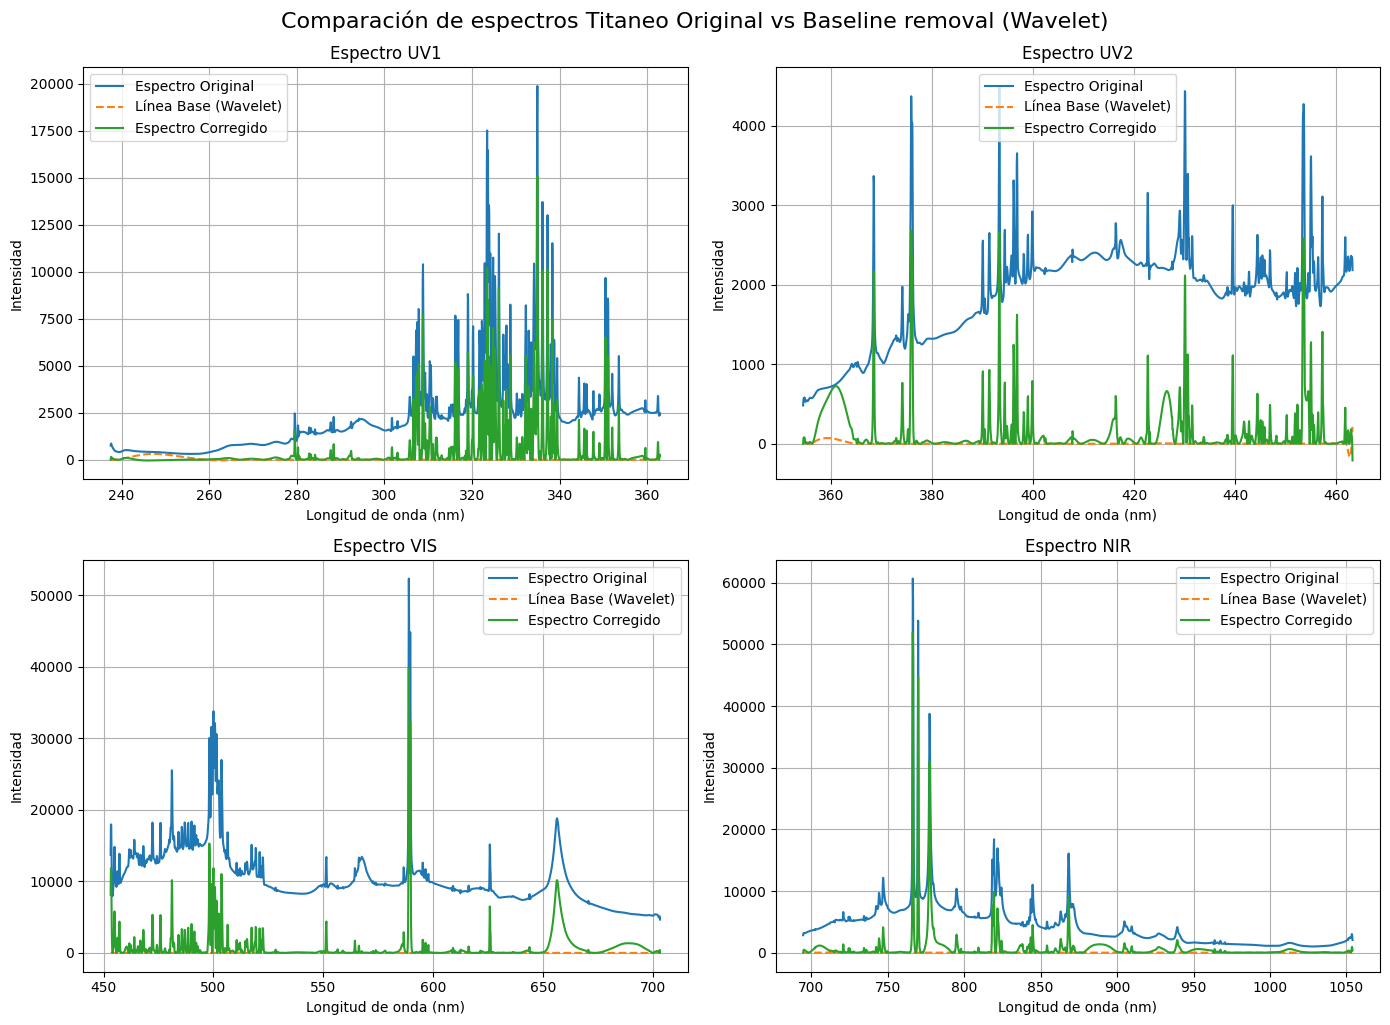

In [7]:
espectro_UV1_baseless, continuum_UV1 = iterative_wavelet_continuum_removal(espectro_UV1, wavelet='db13', L_max=None, L_min=3, max_iter=10, tol=1e-3)
espectro_UV2_baseless, continuum_UV2 = iterative_wavelet_continuum_removal(espectro_UV2, wavelet='db13', L_max=None, L_min=3, max_iter=10, tol=1e-3)
espectro_VIS_baseless, continuum_VIS = iterative_wavelet_continuum_removal(espectro_VIS, wavelet='db13', L_max=None, L_min=3, max_iter=10, tol=1e-3)
espectro_NIR_baseless, continuum_NIR = iterative_wavelet_continuum_removal(espectro_NIR, wavelet='db13', L_max=None, L_min=3, max_iter=10, tol=1e-3)

# Visualizar espectros antes y después del denoising
nombres = ['UV1', 'UV2', 'VIS', 'NIR']
espectros_originales = [espectro_UV1, espectro_UV2, espectro_VIS, espectro_NIR]
espectros_denoised = [espectro_UV1_baseless, espectro_UV2_baseless, espectro_VIS_baseless, espectro_NIR_baseless]
wavelengths = [wavelength_UV1, wavelength_UV2, wavelength_VIS, wavelength_NIR]
continuum = [continuum_UV1, continuum_UV2, continuum_VIS, continuum_NIR]

plt.figure(figsize=(14, 10))

for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.plot(wavelengths[i], espectros_originales[i], label='Espectro Original')
    plt.plot(wavelengths[i],continuum[i], label="Línea Base (Wavelet)", linestyle='--')
    plt.plot(wavelengths[i], espectros_denoised[i], label='Espectro Corregido')
    plt.title(f"Espectro {nombres[i]}")
    plt.xlabel("Longitud de onda (nm)")
    plt.ylabel("Intensidad")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.suptitle("Comparación de espectros Titaneo Original vs Baseline removal (Wavelet)", y=1.02, fontsize=16)
plt.show()

#### Rolling Ball

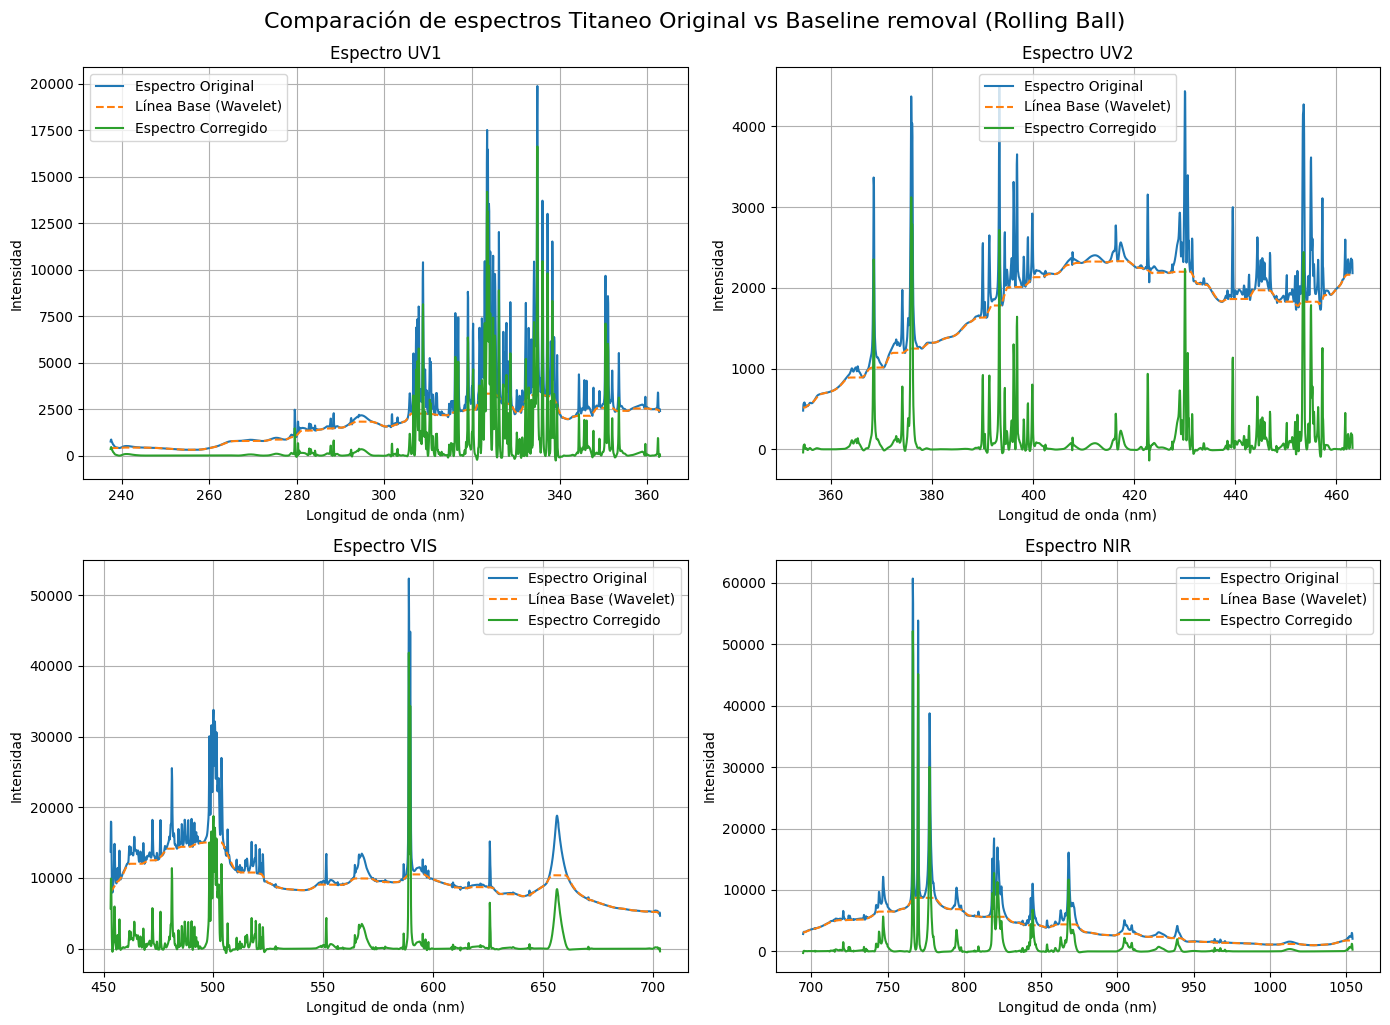

In [8]:
espectro_UV1_baseless, continuum_UV1 = rolling_ball_baseline(espectro_UV1, wm=70, ws=20)
espectro_UV2_baseless, continuum_UV2 = rolling_ball_baseline(espectro_UV2, wm=70, ws=20)
espectro_VIS_baseless, continuum_VIS = rolling_ball_baseline(espectro_VIS, wm=70, ws=20)
espectro_NIR_baseless, continuum_NIR = rolling_ball_baseline(espectro_NIR, wm=70, ws=20)

# Visualizar espectros antes y después del denoising
nombres = ['UV1', 'UV2', 'VIS', 'NIR']
espectros_originales = [espectro_UV1, espectro_UV2, espectro_VIS, espectro_NIR]
espectros_denoised = [espectro_UV1_baseless, espectro_UV2_baseless, espectro_VIS_baseless, espectro_NIR_baseless]
wavelengths = [wavelength_UV1, wavelength_UV2, wavelength_VIS, wavelength_NIR]
continuum = [continuum_UV1, continuum_UV2, continuum_VIS, continuum_NIR]

plt.figure(figsize=(14, 10))

for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.plot(wavelengths[i], espectros_originales[i], label='Espectro Original')
    plt.plot(wavelengths[i],continuum[i], label="Línea Base (Wavelet)", linestyle='--')
    plt.plot(wavelengths[i], espectros_denoised[i], label='Espectro Corregido')
    plt.title(f"Espectro {nombres[i]}")
    plt.xlabel("Longitud de onda (nm)")
    plt.ylabel("Intensidad")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.suptitle("Comparación de espectros Titaneo Original vs Baseline removal (Rolling Ball)", y=1.02, fontsize=16)
plt.show()

#### RBE (Robust Baseline Estimation)

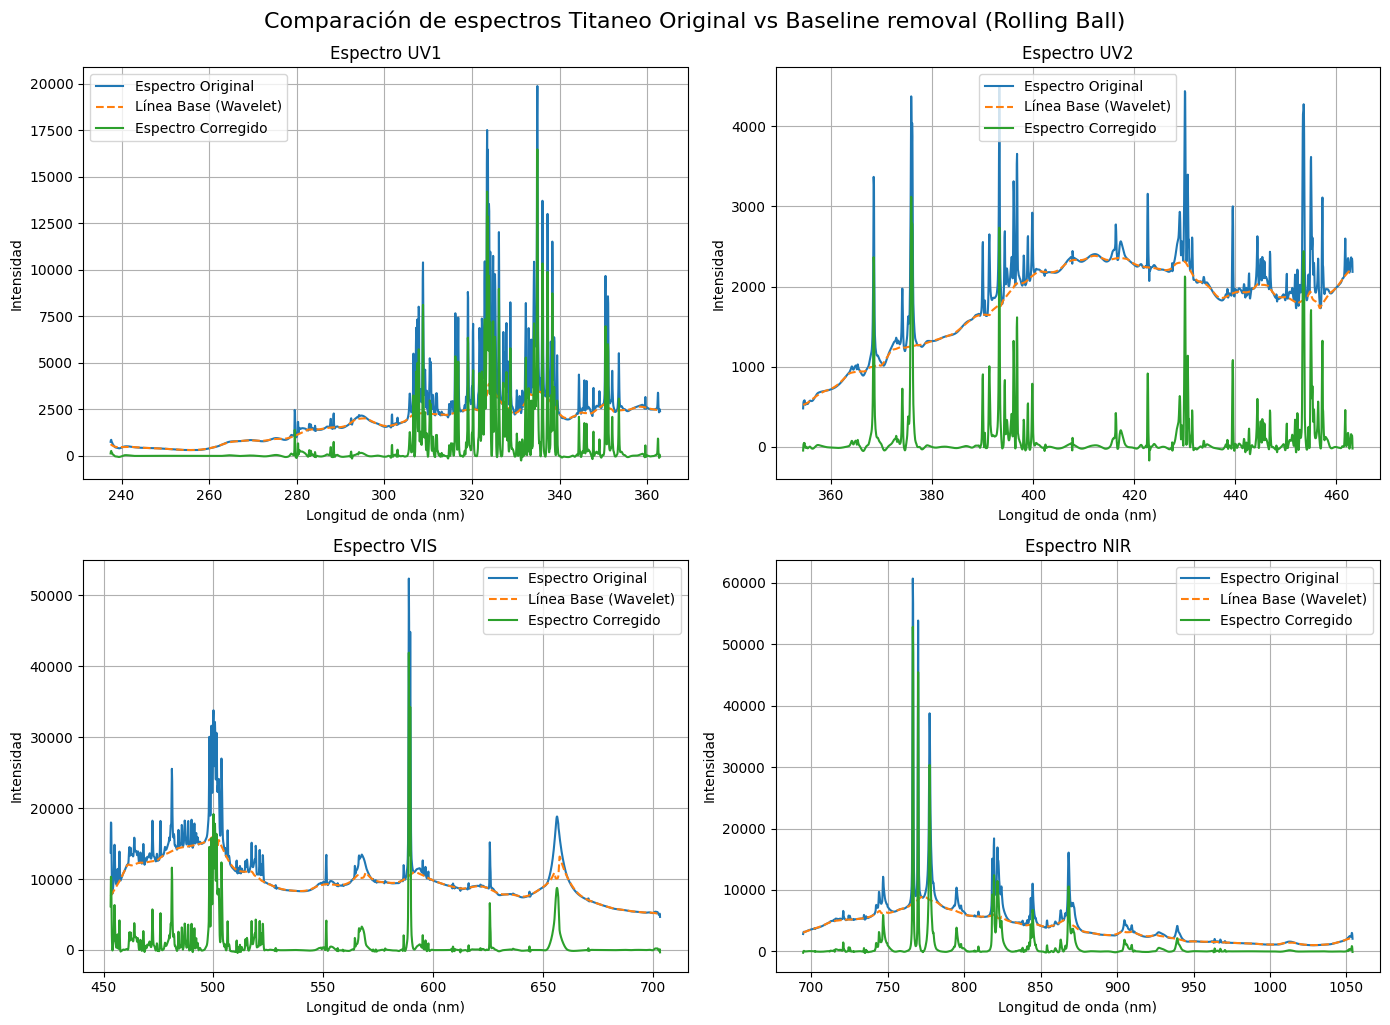

In [ ]:
espectro_UV1_baseless, continuum_UV1 = robust_baseline_estimation(espectro_UV1, span=0.05, max_iter=10, b=3.5, tol=1e-3)
espectro_UV2_baseless, continuum_UV2 = robust_baseline_estimation(espectro_UV2, span=0.05, max_iter=10, b=3.5, tol=1e-3)
espectro_VIS_baseless, continuum_VIS = robust_baseline_estimation(espectro_VIS, span=0.05, max_iter=10, b=3.5, tol=1e-3)
espectro_NIR_baseless, continuum_NIR = robust_baseline_estimation(espectro_NIR, span=0.05, max_iter=10, b=3.5, tol=1e-3)

# Visualizar espectros antes y después del denoising
nombres = ['UV1', 'UV2', 'VIS', 'NIR']
espectros_originales = [espectro_UV1, espectro_UV2, espectro_VIS, espectro_NIR]
espectros_denoised = [espectro_UV1_baseless, espectro_UV2_baseless, espectro_VIS_baseless, espectro_NIR_baseless]
wavelengths = [wavelength_UV1, wavelength_UV2, wavelength_VIS, wavelength_NIR]
continuum = [continuum_UV1, continuum_UV2, continuum_VIS, continuum_NIR]

plt.figure(figsize=(14, 10))

for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.plot(wavelengths[i], espectros_originales[i], label='Espectro Original')
    plt.plot(wavelengths[i],continuum[i], label="Línea Base (Wavelet)", linestyle='--')
    plt.plot(wavelengths[i], espectros_denoised[i], label='Espectro Corregido')
    plt.title(f"Espectro {nombres[i]}")
    plt.xlabel("Longitud de onda (nm)")
    plt.ylabel("Intensidad")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.suptitle("Comparación de espectros Titaneo Original vs Baseline removal (RBE)", y=1.02, fontsize=16)
plt.show()

## **Archivos Sulfatos**

In [41]:
# Ruta relativa desde Pre_Processing a los espectros
ruta_espectros = os.path.join('..', 'Spectra', '20250321_First_test')

UV1 = os.path.join(ruta_espectros, 'Sulfato50_shot01_7324767SP.txt')
UV2 = os.path.join(ruta_espectros, 'Sulfato50_shot01_7324768SP.txt')
VIS = os.path.join(ruta_espectros, 'Sulfato50_shot01_7324769SP.txt')
NIR = os.path.join(ruta_espectros, 'Sulfato50_shot01_7324770SP.txt')

espectro_UV1, wavelength_UV1 = leer_archivo_txt(UV1)
espectro_UV2, wavelength_UV2 = leer_archivo_txt(UV2)
espectro_VIS, wavelength_VIS = leer_archivo_txt(VIS)
espectro_NIR, wavelength_NIR  = leer_archivo_txt(NIR)

espectro_UV1 = denoise_spectrum_uwt(espectro_UV1)
espectro_UV2 = denoise_spectrum_uwt(espectro_UV2)
espectro_VIS = denoise_spectrum_uwt(espectro_VIS)
espectro_NIR = denoise_spectrum_uwt(espectro_NIR)

#### Wavelet iterado

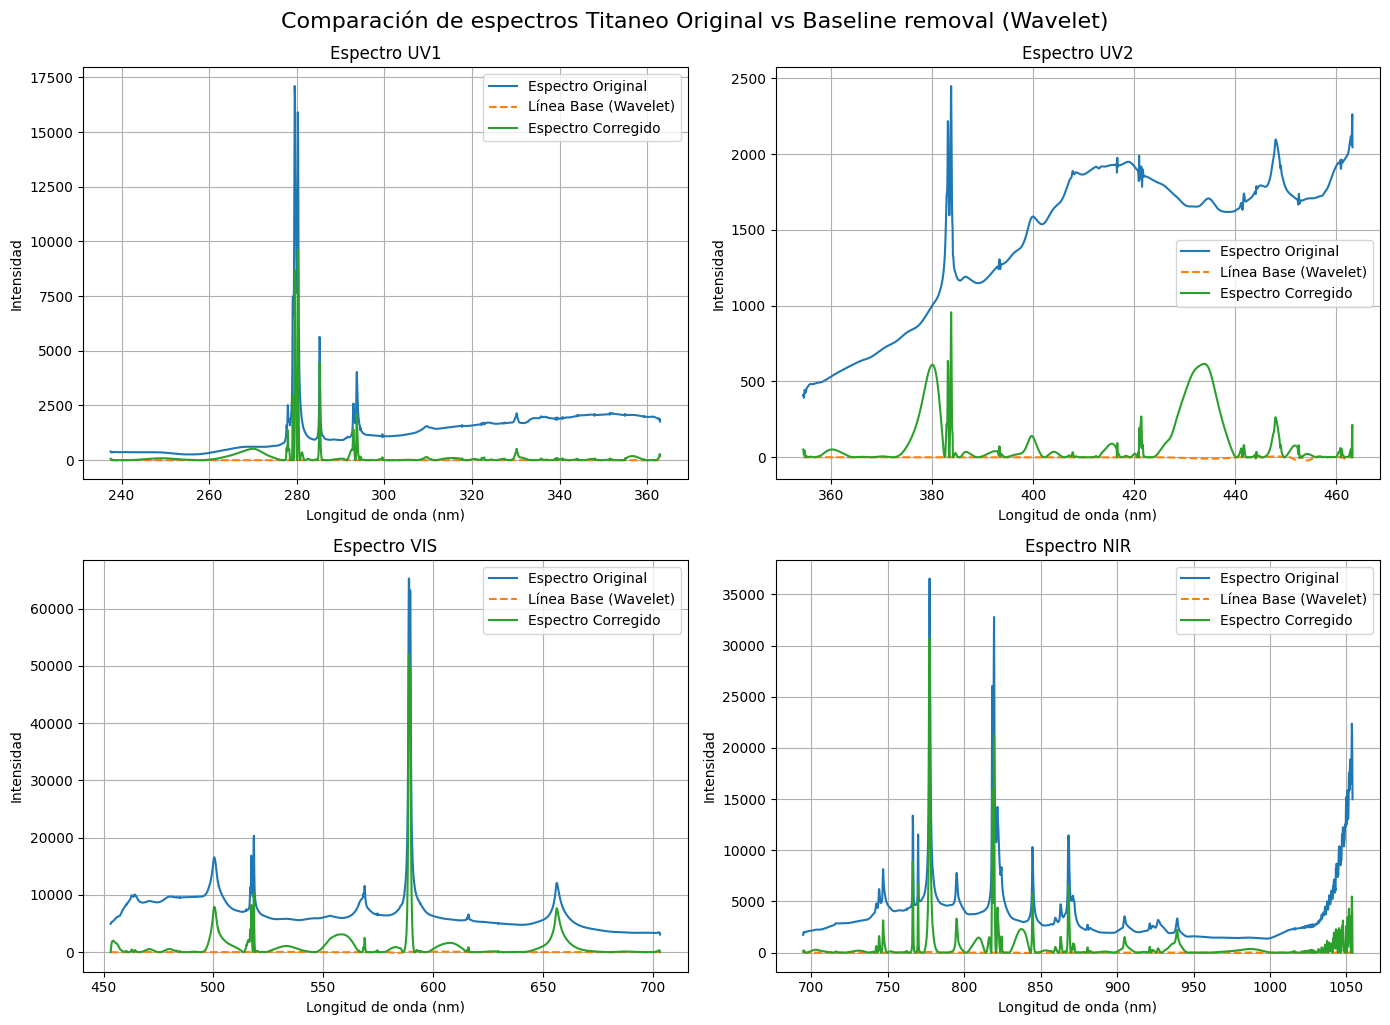

In [46]:
espectro_UV1_baseless, continuum_UV1 = iterative_wavelet_continuum_removal(espectro_UV1, wavelet='db13', L_max=None, L_min=3, max_iter=10, tol=1e-3)
espectro_UV2_baseless, continuum_UV2 = iterative_wavelet_continuum_removal(espectro_UV2, wavelet='db13', L_max=7, L_min=3, max_iter=10, tol=1e-3)
espectro_VIS_baseless, continuum_VIS = iterative_wavelet_continuum_removal(espectro_VIS, wavelet='db13', L_max=None, L_min=3, max_iter=10, tol=1e-3)
espectro_NIR_baseless, continuum_NIR = iterative_wavelet_continuum_removal(espectro_NIR, wavelet='db13', L_max=None, L_min=3, max_iter=10, tol=1e-3)

# Visualizar espectros antes y después del denoising
nombres = ['UV1', 'UV2', 'VIS', 'NIR']
espectros_originales = [espectro_UV1, espectro_UV2, espectro_VIS, espectro_NIR]
espectros_denoised = [espectro_UV1_baseless, espectro_UV2_baseless, espectro_VIS_baseless, espectro_NIR_baseless]
wavelengths = [wavelength_UV1, wavelength_UV2, wavelength_VIS, wavelength_NIR]
continuum = [continuum_UV1, continuum_UV2, continuum_VIS, continuum_NIR]

plt.figure(figsize=(14, 10))

for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.plot(wavelengths[i], espectros_originales[i], label='Espectro Original')
    plt.plot(wavelengths[i],continuum[i], label="Línea Base (Wavelet)", linestyle='--')
    plt.plot(wavelengths[i], espectros_denoised[i], label='Espectro Corregido')
    plt.title(f"Espectro {nombres[i]}")
    plt.xlabel("Longitud de onda (nm)")
    plt.ylabel("Intensidad")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.suptitle("Comparación de espectros Titaneo Original vs Baseline removal (Wavelet)", y=1.02, fontsize=16)
plt.show()

#### Rolling Ball

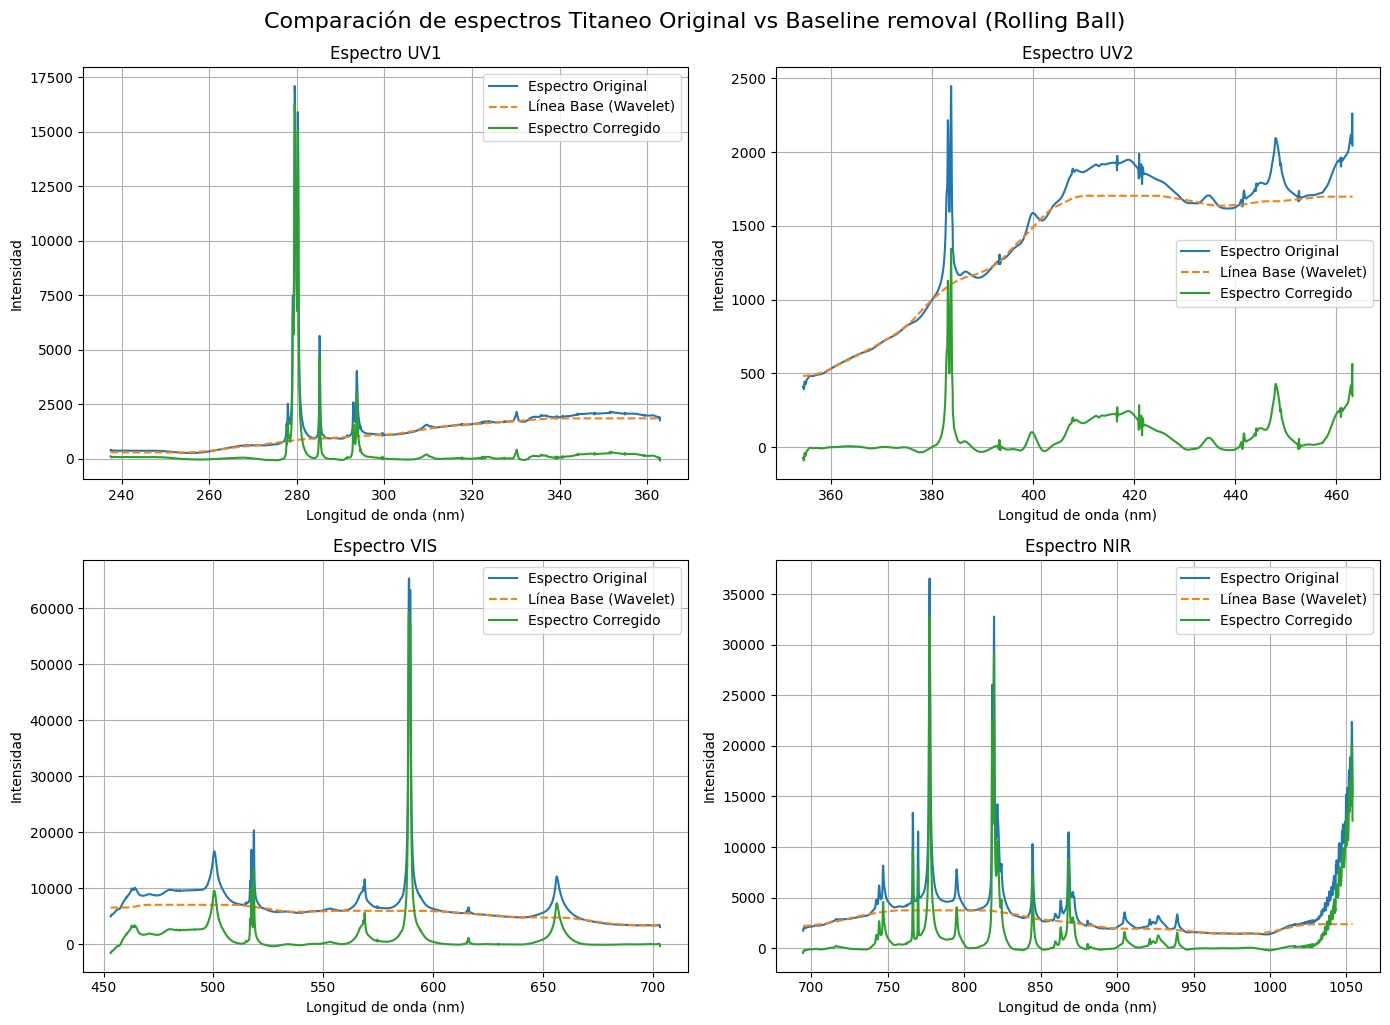

In [47]:
espectro_UV1_baseless, continuum_UV1 = rolling_ball_baseline(espectro_UV1, wm=430, ws=175)
espectro_UV2_baseless, continuum_UV2 = rolling_ball_baseline(espectro_UV2, wm=430, ws=175)
espectro_VIS_baseless, continuum_VIS = rolling_ball_baseline(espectro_VIS, wm=430, ws=175)
espectro_NIR_baseless, continuum_NIR = rolling_ball_baseline(espectro_NIR, wm=430, ws=175)

# Visualizar espectros antes y después del denoising
nombres = ['UV1', 'UV2', 'VIS', 'NIR']
espectros_originales = [espectro_UV1, espectro_UV2, espectro_VIS, espectro_NIR]
espectros_denoised = [espectro_UV1_baseless, espectro_UV2_baseless, espectro_VIS_baseless, espectro_NIR_baseless]
wavelengths = [wavelength_UV1, wavelength_UV2, wavelength_VIS, wavelength_NIR]
continuum = [continuum_UV1, continuum_UV2, continuum_VIS, continuum_NIR]

plt.figure(figsize=(14, 10))

for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.plot(wavelengths[i], espectros_originales[i], label='Espectro Original')
    plt.plot(wavelengths[i],continuum[i], label="Línea Base (Wavelet)", linestyle='--')
    plt.plot(wavelengths[i], espectros_denoised[i], label='Espectro Corregido')
    plt.title(f"Espectro {nombres[i]}")
    plt.xlabel("Longitud de onda (nm)")
    plt.ylabel("Intensidad")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.suptitle("Comparación de espectros Titaneo Original vs Baseline removal (Rolling Ball)", y=1.02, fontsize=16)
plt.show()

#### RBE (Robust Baseline Estimation)

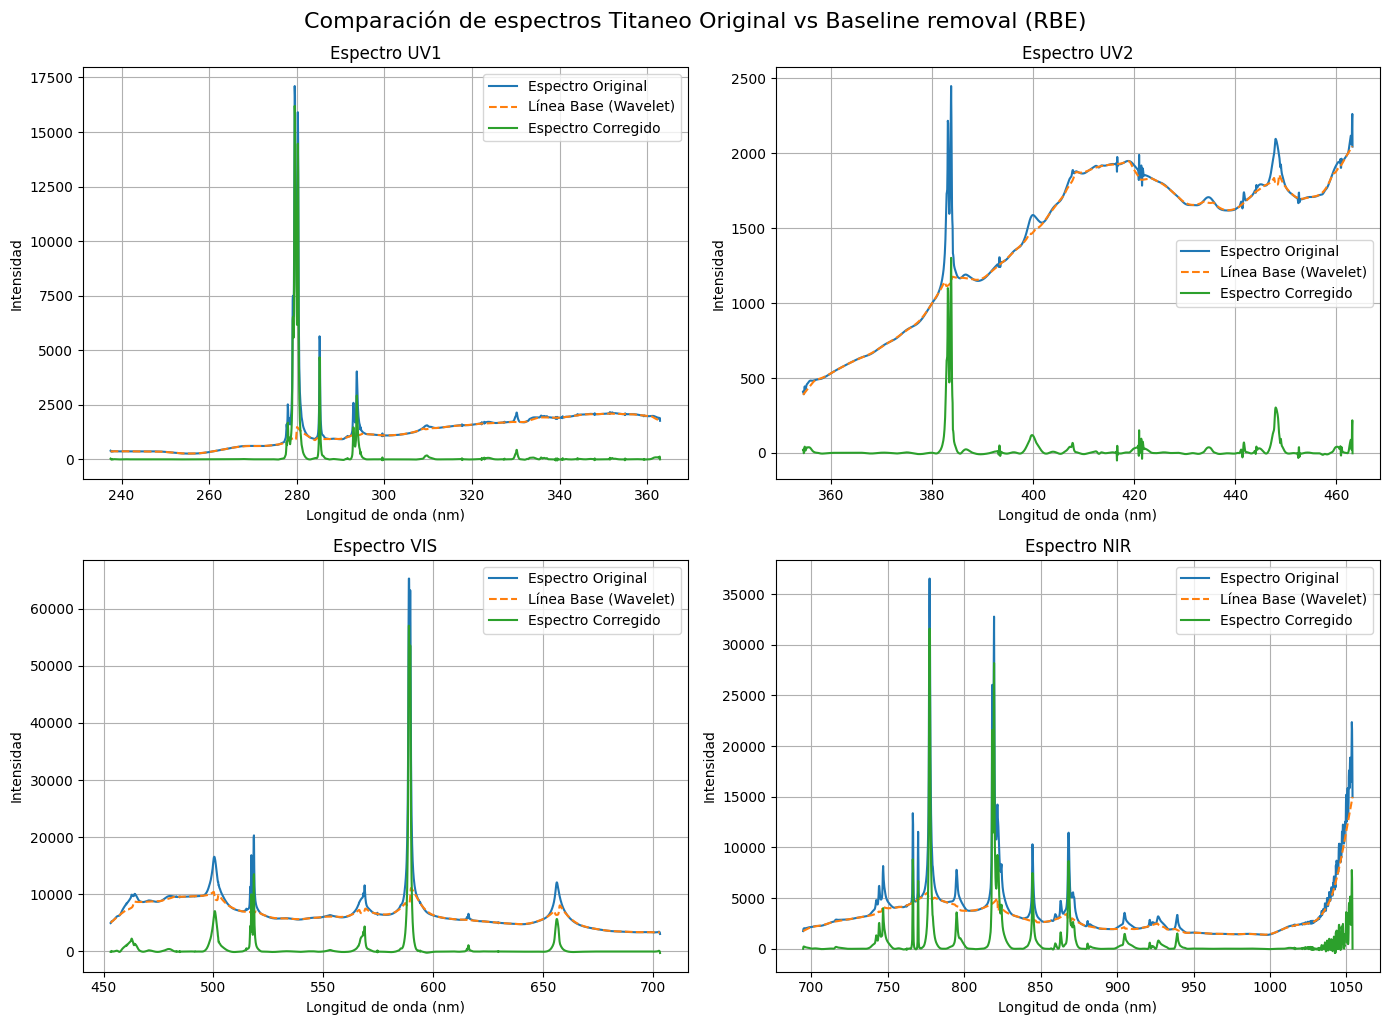

In [ ]:
espectro_UV1_baseless, continuum_UV1 = robust_baseline_estimation(espectro_UV1, span=0.05, max_iter=10, b=3.5, tol=1e-3)
espectro_UV2_baseless, continuum_UV2 = robust_baseline_estimation(espectro_UV2, span=0.05, max_iter=10, b=3.5, tol=1e-3)
espectro_VIS_baseless, continuum_VIS = robust_baseline_estimation(espectro_VIS, span=0.05, max_iter=10, b=3.5, tol=1e-3)
espectro_NIR_baseless, continuum_NIR = robust_baseline_estimation(espectro_NIR, span=0.05, max_iter=10, b=3.5, tol=1e-3)

# Visualizar espectros antes y después del denoising
nombres = ['UV1', 'UV2', 'VIS', 'NIR']
espectros_originales = [espectro_UV1, espectro_UV2, espectro_VIS, espectro_NIR]
espectros_denoised = [espectro_UV1_baseless, espectro_UV2_baseless, espectro_VIS_baseless, espectro_NIR_baseless]
wavelengths = [wavelength_UV1, wavelength_UV2, wavelength_VIS, wavelength_NIR]
continuum = [continuum_UV1, continuum_UV2, continuum_VIS, continuum_NIR]

plt.figure(figsize=(14, 10))

for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.plot(wavelengths[i], espectros_originales[i], label='Espectro Original')
    plt.plot(wavelengths[i],continuum[i], label="Línea Base (Wavelet)", linestyle='--')
    plt.plot(wavelengths[i], espectros_denoised[i], label='Espectro Corregido')
    plt.title(f"Espectro {nombres[i]}")
    plt.xlabel("Longitud de onda (nm)")
    plt.ylabel("Intensidad")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.suptitle("Comparación de espectros Titaneo Original vs Baseline removal (RBE)", y=1.02, fontsize=16)
plt.show()